In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('encoder.py'), '..')))
from encoder import EncoderBuilder, Sampling

import tensorflow as tf
from keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import h5py

2025-08-18 16:52:30.462324: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-18 16:52:31.970955: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-18 16:52:35.230000: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
encoder_model = load_model("/home/chua/projects/Autoencoder Notes/Interpretable Sound Generation/initial_encoder_vae_log_mel_spec.keras",
    custom_objects={
        "Sampling" : Sampling
    })

I0000 00:00:1755507161.119610     887 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9711 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
with h5py.File('Dataset/log_mel_spec_data_dataset.h5', 'r') as h5f:
    log_mel_spec_data_train = h5f['train'][:]
    log_melspec_data_labels = h5f['label'][:]

In [4]:
mean_vector, log_variance_vector, latent_representation = encoder_model.predict(log_mel_spec_data_train)

2025-08-18 16:52:50.065343: I external/local_xla/xla/service/service.cc:163] XLA service 0x73ed9800adc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-18 16:52:50.065384: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-08-18 16:52:50.101330: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-18 16:52:50.211728: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


 25/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step

I0000 00:00:1755507173.351607     986 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step


In [5]:
log_variance_score = np.mean(log_variance_vector, axis=1)

In [6]:
log_variance_score.shape

(30000,)

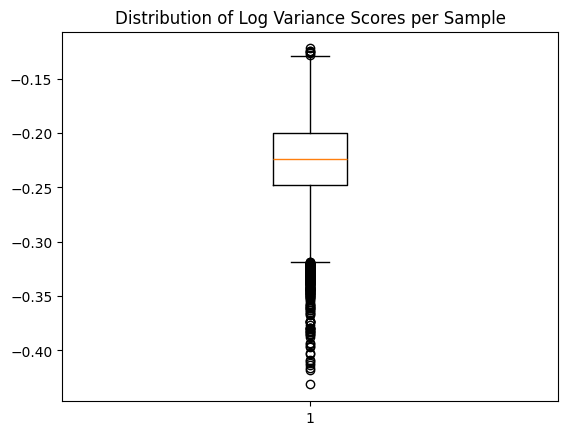

In [7]:
plt.boxplot(log_variance_score)
plt.title("Distribution of Log Variance Scores per Sample")
plt.show()

In [19]:
q1 = np.percentile(log_variance_score, 25)
q3 = np.percentile(log_variance_score, 75)
iqr = q3 - q1

upper_threshold = q3 + 1.5 * iqr
filtered_indices = np.where(log_variance_score < upper_threshold)[0]

In [20]:
log_var_filtered = log_variance_vector[filtered_indices]

In [21]:
log_var_filtered_score = np.mean(log_var_filtered, axis=1)

Ugh 6 sample ra ang outliers

In [22]:
log_var_filtered_score.shape

(29994,)

{'whiskers': [<matplotlib.lines.Line2D at 0x73ee7002f1a0>,
 'caps': [<matplotlib.lines.Line2D at 0x73ee7002eff0>,
 'boxes': [<matplotlib.lines.Line2D at 0x73ee700a5040>],
 'medians': [<matplotlib.lines.Line2D at 0x73ee70018410>],
 'fliers': [<matplotlib.lines.Line2D at 0x73ee7001aff0>],
 'means': []}

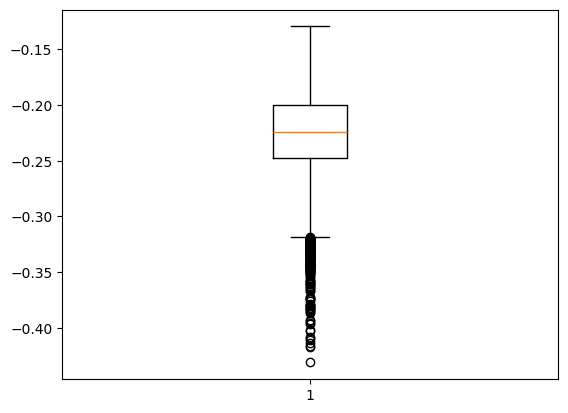

In [23]:
plt.boxplot(log_var_filtered_score)

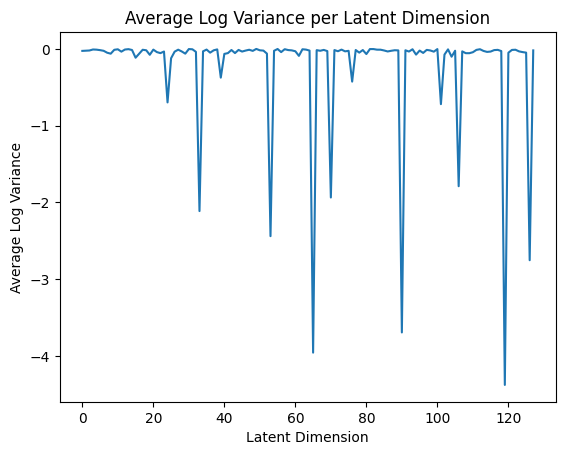

In [13]:
dim_variance = np.mean(log_variance_vector, axis=0)
plt.plot(dim_variance)
plt.title("Average Log Variance per Latent Dimension")
plt.xlabel("Latent Dimension")
plt.ylabel("Average Log Variance")
plt.show()